# 02 — Comparison & KPIs: Agenda Distortion Metrics

Compares topic structures across the alt media and mainstream corpora using literature-grounded KPIs.

All metrics are designed to detect **agenda distortion** — systematic differences in which topics receive coverage and how much — not framing or sentiment differences within shared topics.

In [3]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "experiments" / "agenda_distortion" / "outputs"

print(f"Loading outputs from: {OUTPUT_DIR}")

Loading outputs from: /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs


## Load Outputs from Notebook 01

In [4]:
alt_topic_info = pd.read_csv(OUTPUT_DIR / "alt_media_topic_info.csv")
ms_topic_info = pd.read_csv(OUTPUT_DIR / "mainstream_topic_info.csv")

alt_doc_topics = pd.read_csv(OUTPUT_DIR / "alt_media_doc_topics.csv")
ms_doc_topics = pd.read_csv(OUTPUT_DIR / "mainstream_doc_topics.csv")

alt_topic_embeddings = np.load(OUTPUT_DIR / "alt_media_topic_embeddings.npy")
ms_topic_embeddings = np.load(OUTPUT_DIR / "mainstream_topic_embeddings.npy")

with open(OUTPUT_DIR / "alt_media_topic_words.json") as f:
    alt_word_lists = json.load(f)
with open(OUTPUT_DIR / "mainstream_topic_words.json") as f:
    ms_word_lists = json.load(f)

print(f"Alt media:  {len(alt_doc_topics):,} docs, {len(alt_word_lists)} topics")
print(f"Mainstream: {len(ms_doc_topics):,} docs, {len(ms_word_lists)} topics")

Alt media:  14,183 docs, 130 topics
Mainstream: 6,272 docs, 84 topics


## KPI 1 — Jensen-Shannon Divergence

JSD measures the divergence between the normalized topic prevalence distributions of the two corpora.

- JSD = 0: identical distributions (same agenda)
- JSD = 1: completely disjoint distributions (entirely different agendas)

**Interpretation threshold**: A JSD > 0.3 suggests meaningful agenda divergence (cf. DiMaggio et al., 2013, who use JSD on topic distributions to measure ideological distance between corpora).

**Note**: Since the two models produce different topic spaces, we first need to align topics across models. We do this by computing a shared topic space via embedding similarity — topics from both models that are cosine-similar above a threshold are treated as the same topic.

In [5]:
from scipy.spatial.distance import jensenshannon
from sklearn.metrics.pairwise import cosine_similarity

# Build cross-model topic similarity matrix
cross_sim = cosine_similarity(alt_topic_embeddings, ms_topic_embeddings)

# Align topics: for each alt topic, find best-matching mainstream topic
ALIGN_THRESHOLD = 0.65

alt_topic_ids = [int(t) for t in alt_word_lists.keys()]
ms_topic_ids = [int(t) for t in ms_word_lists.keys()]

# Build a unified topic space
aligned_topics = []  # list of (unified_id, alt_topic_id_or_None, ms_topic_id_or_None)
used_ms = set()
unified_id = 0

for i, alt_id in enumerate(alt_topic_ids):
    best_j = int(cross_sim[i].argmax())
    best_sim = float(cross_sim[i, best_j])
    ms_id = ms_topic_ids[best_j]
    if best_sim >= ALIGN_THRESHOLD and best_j not in used_ms:
        aligned_topics.append((unified_id, alt_id, ms_id))
        used_ms.add(best_j)
    else:
        aligned_topics.append((unified_id, alt_id, None))
    unified_id += 1

# Add unmatched mainstream topics
for j, ms_id in enumerate(ms_topic_ids):
    if j not in used_ms:
        aligned_topics.append((unified_id, None, ms_id))
        unified_id += 1

n_unified = len(aligned_topics)
n_shared = sum(1 for _, a, m in aligned_topics if a is not None and m is not None)
print(f"Unified topic space: {n_unified} topics ({n_shared} shared, {n_unified - n_shared} unique)")

# Build normalized prevalence vectors over unified space
alt_non_outlier = alt_doc_topics.loc[alt_doc_topics["topic"] != -1]
ms_non_outlier = ms_doc_topics.loc[ms_doc_topics["topic"] != -1]

alt_counts = alt_non_outlier["topic"].value_counts()
ms_counts = ms_non_outlier["topic"].value_counts()

alt_prev = np.zeros(n_unified)
ms_prev = np.zeros(n_unified)

for uid, alt_id, ms_id in aligned_topics:
    if alt_id is not None:
        alt_prev[uid] = alt_counts.get(alt_id, 0)
    if ms_id is not None:
        ms_prev[uid] = ms_counts.get(ms_id, 0)

# Normalize to probability distributions
alt_prev_norm = alt_prev / alt_prev.sum() if alt_prev.sum() > 0 else alt_prev
ms_prev_norm = ms_prev / ms_prev.sum() if ms_prev.sum() > 0 else ms_prev

jsd_score = float(jensenshannon(alt_prev_norm, ms_prev_norm, base=2) ** 2)
print(f"\nJensen-Shannon Divergence (squared): {jsd_score:.4f}")
if jsd_score > 0.3:
    print("→ Above 0.3 threshold: meaningful agenda divergence detected.")
else:
    print("→ Below 0.3 threshold: limited divergence. Consider adjusting topic granularity.")

Unified topic space: 173 topics (41 shared, 132 unique)

Jensen-Shannon Divergence (squared): 0.5228
→ Above 0.3 threshold: meaningful agenda divergence detected.


## KPI 2 — Topic Embedding Cosine Similarity Matrix

Pairwise cosine similarity between all topic centroid vectors across the two models. Low average similarity = structurally different topic spaces.

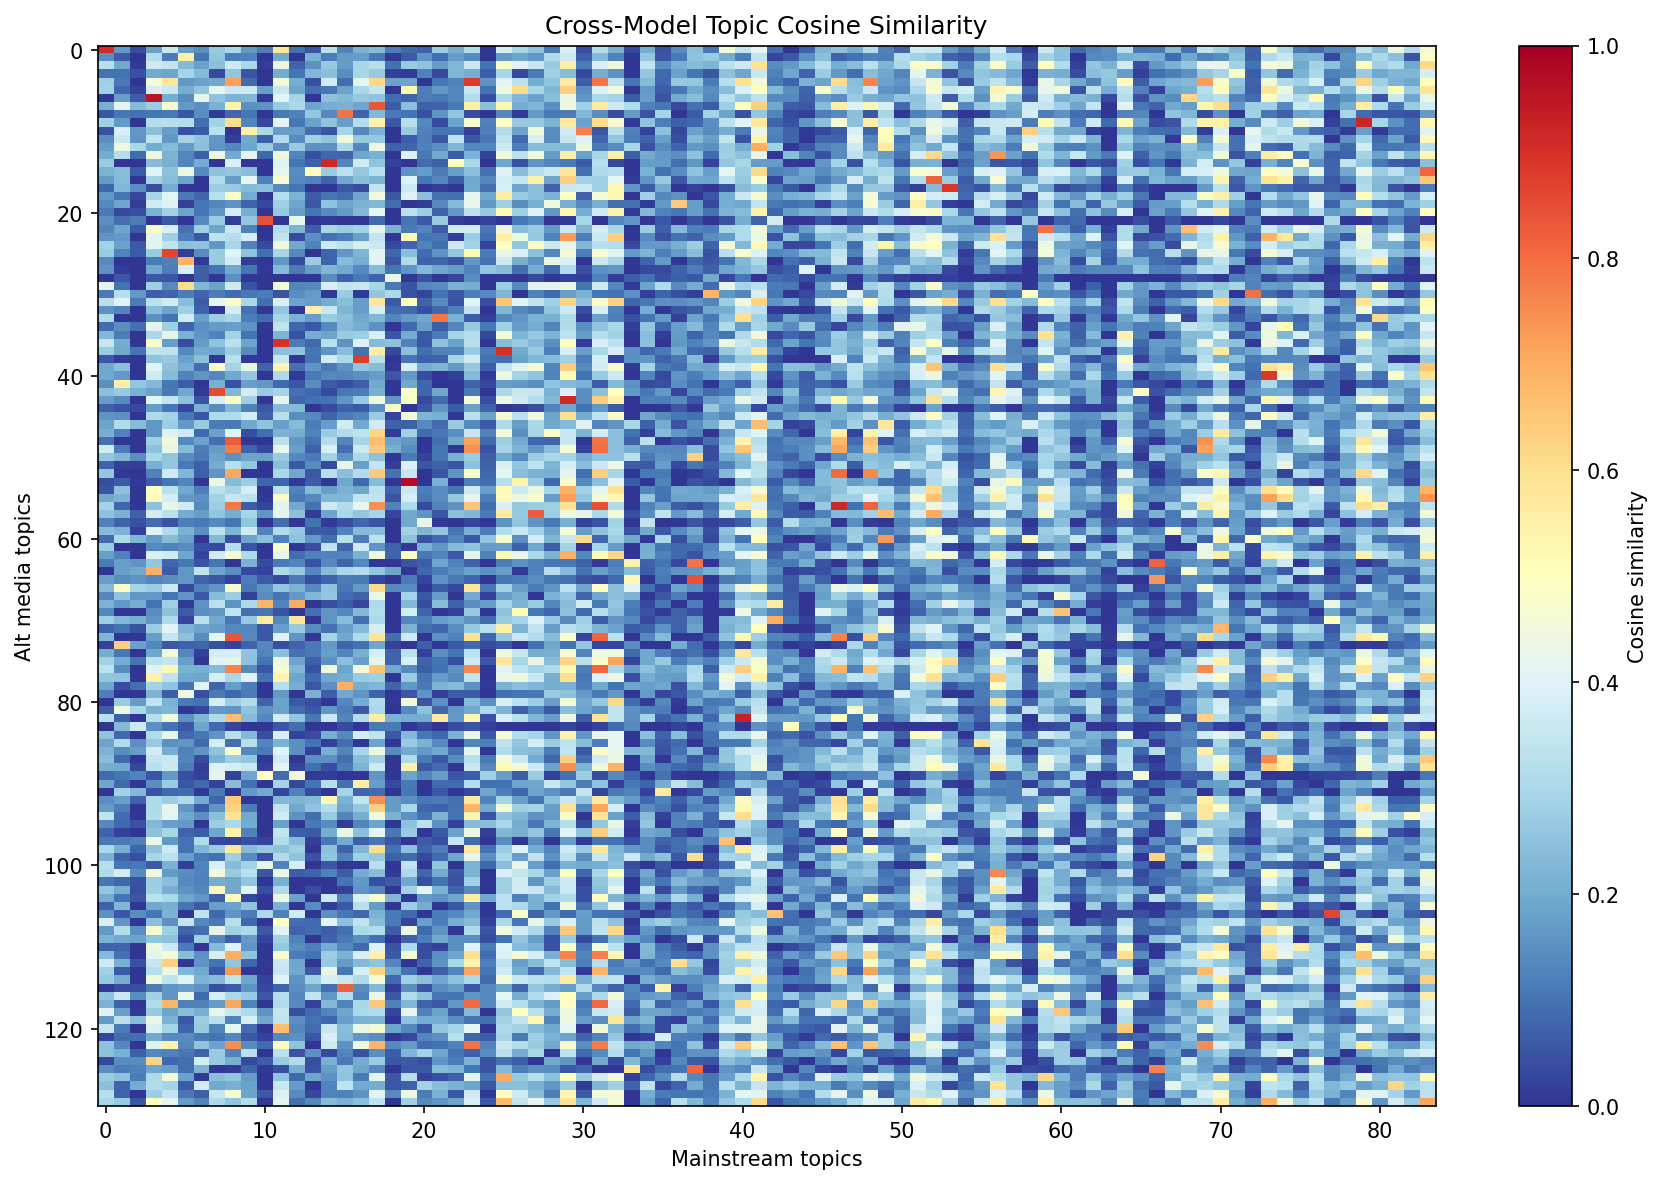

Average best-match similarity: 0.673
Average overall similarity:    0.200
→ Low average similarity: structurally different topic spaces.


In [6]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)
im = ax.imshow(cross_sim, cmap="RdYlBu_r", vmin=0, vmax=1, aspect="auto")
ax.set_xlabel("Mainstream topics")
ax.set_ylabel("Alt media topics")
ax.set_title("Cross-Model Topic Cosine Similarity")
fig.colorbar(im, ax=ax, label="Cosine similarity")
fig.tight_layout()
plt.show()

avg_max_sim = float(cross_sim.max(axis=1).mean())
avg_overall_sim = float(cross_sim.mean())
print(f"Average best-match similarity: {avg_max_sim:.3f}")
print(f"Average overall similarity:    {avg_overall_sim:.3f}")
if avg_overall_sim < 0.5:
    print("→ Low average similarity: structurally different topic spaces.")
elif avg_overall_sim > 0.7:
    print("→ High average similarity: topics may be too similar. Check corpus quality.")
else:
    print("→ Moderate similarity: some shared structure with meaningful differences.")

## KPI 3 — Topic Diversity

For each model: proportion of unique words across top-10 words of all topics. Higher = more diverse agenda.

In [7]:
def compute_topic_diversity(word_lists: dict, top_n: int = 10) -> float:
    """Proportion of unique words across top-N words of all topics."""
    all_words = []
    for words in word_lists.values():
        all_words.extend(words[:top_n])
    if not all_words:
        return 0.0
    return len(set(all_words)) / len(all_words)


alt_diversity = compute_topic_diversity(alt_word_lists)
ms_diversity = compute_topic_diversity(ms_word_lists)

print(f"Alt media topic diversity:  {alt_diversity:.3f}")
print(f"Mainstream topic diversity: {ms_diversity:.3f}")
print(f"Delta: {alt_diversity - ms_diversity:+.3f}")
if alt_diversity < ms_diversity:
    print("→ Alt media topics share more vocabulary — potentially narrower thematic focus.")
else:
    print("→ Alt media topics are more lexically diverse — broader vocabulary spread.")

Alt media topic diversity:  0.758
Mainstream topic diversity: 0.829
Delta: -0.071
→ Alt media topics share more vocabulary — potentially narrower thematic focus.


## KPI 4 — Prevalence Delta

For each shared/aligned topic: normalized prevalence difference between corpora. Which topics are systematically over- or under-represented in alt media?

In [8]:
prevalence_rows = []
for uid, alt_id, ms_id in aligned_topics:
    alt_p = float(alt_prev_norm[uid])
    ms_p = float(ms_prev_norm[uid])
    delta = alt_p - ms_p

    # Build label from whichever model contributed
    if alt_id is not None:
        words = alt_word_lists.get(str(alt_id), [])
    elif ms_id is not None:
        words = ms_word_lists.get(str(ms_id), [])
    else:
        words = []
    label = ", ".join(words[:5])

    prevalence_rows.append({
        "unified_topic": uid,
        "alt_topic_id": alt_id,
        "ms_topic_id": ms_id,
        "label": label,
        "alt_prevalence": alt_p,
        "ms_prevalence": ms_p,
        "delta": delta,
    })

prevalence_df = pd.DataFrame(prevalence_rows).sort_values("delta", ascending=False)

print("Top 10 topics OVER-represented in alt media vs mainstream:")
display(prevalence_df.head(10)[["label", "alt_prevalence", "ms_prevalence", "delta"]])

print("\nTop 10 topics UNDER-represented in alt media vs mainstream:")
display(prevalence_df.tail(10)[["label", "alt_prevalence", "ms_prevalence", "delta"]])

Top 10 topics OVER-represented in alt media vs mainstream:


,label,alt_prevalence,ms_prevalence,delta
1,"polizei, mann, täter, jährige, verletzt",0.037354,0.000000,0.037354
2,"zdf, günther, lanz, ard, ruhs",0.029503,0.000000,0.029503
3,"kirk, charlie, charlie kirk, kirks, mord",0.021889,0.000000,0.021889
5,"wegner, berliner, strom, stromausfall, anschlag",0.019629,0.000000,0.019629
11,"afd, chrupalla, familienunternehmer, wehrpflic...",0.015346,0.000000,0.015346
18,"moderator, purrucker, geht direkt, aufzeichnun...",0.013205,0.000000,0.013205
19,"trumps, donald, donald trump, weißen, präsidenten",0.012491,0.000000,0.012491
20,"weimer, wolfram, wolfram weimer, group, media ...",0.012134,0.000000,0.012134
9,"nabu, selensky, ukrainischen, minditsch, selen...",0.016417,0.004505,0.011911
24,"demokratie, meinungsfreiheit, rechts, freiheit...",0.010707,0.000000,0.010707



Top 10 topics UNDER-represented in alt media vs mainstream:


,label,alt_prevalence,ms_prevalence,delta
137,"proteste, wahl, kambodscha, wahlen, thailand",0.000000,0.012873,-0.012873
6,"venezuela, maduro, venezuelas, caracas, venezo...",0.017488,0.031109,-0.013622
136,"netflix, warner, film, paramount, warner bros",0.000000,0.014160,-0.014160
135,"medikamente, antibiotika, patienten, grippe, a...",0.000000,0.015018,-0.015018
134,"prozess, tat, gericht, verfahren, urteil",0.000000,0.016520,-0.016520
133,"wohnungen, wohnung, mieten, wohnraum, mieter",0.000000,0.017378,-0.017378
132,"überschwemmungen, philippinen, hurrikan, ums l...",0.000000,0.019309,-0.019309
0,"israel, hamas, gaza, israelischen, gazastreifen",0.060195,0.094186,-0.033991
131,"preise, lebensmittel, verbraucher, weihnachten...",0.000000,0.034542,-0.034542
130,"dax, dollar, punkten, anleger, ki",0.000000,0.038833,-0.038833


## Bootstrap Confidence Intervals

Wrap KPIs 1 and 4 in a bootstrap loop (n=1000, stratified resampling) to produce 95% CIs. This corrects for corpus size imbalance.

In [9]:
from scipy.spatial.distance import jensenshannon as jsd_fn

N_BOOTSTRAP = 1000
rng = np.random.RandomState(42)


def bootstrap_jsd(alt_topics_series, ms_topics_series, aligned_mapping, n_unified, n_boot=1000):
    """Bootstrap JSD between two topic assignment vectors over a unified topic space."""
    jsd_samples = []
    for _ in range(n_boot):
        # Stratified resample within each corpus
        alt_boot = alt_topics_series.sample(n=len(alt_topics_series), replace=True, random_state=rng)
        ms_boot = ms_topics_series.sample(n=len(ms_topics_series), replace=True, random_state=rng)

        alt_c = alt_boot.value_counts()
        ms_c = ms_boot.value_counts()

        a_vec = np.zeros(n_unified)
        m_vec = np.zeros(n_unified)
        for uid, alt_id, ms_id in aligned_mapping:
            if alt_id is not None:
                a_vec[uid] = alt_c.get(alt_id, 0)
            if ms_id is not None:
                m_vec[uid] = ms_c.get(ms_id, 0)

        a_norm = a_vec / a_vec.sum() if a_vec.sum() > 0 else a_vec
        m_norm = m_vec / m_vec.sum() if m_vec.sum() > 0 else m_vec
        jsd_samples.append(float(jsd_fn(a_norm, m_norm, base=2) ** 2))

    return np.array(jsd_samples)


alt_topic_series = alt_non_outlier["topic"]
ms_topic_series = ms_non_outlier["topic"]

jsd_bootstrap = bootstrap_jsd(
    alt_topic_series, ms_topic_series, aligned_topics, n_unified, n_boot=N_BOOTSTRAP
)

jsd_ci_lo = float(np.percentile(jsd_bootstrap, 2.5))
jsd_ci_hi = float(np.percentile(jsd_bootstrap, 97.5))
jsd_mean = float(jsd_bootstrap.mean())

print(f"JSD point estimate: {jsd_score:.4f}")
print(f"JSD bootstrap mean: {jsd_mean:.4f}")
print(f"JSD 95% CI:         [{jsd_ci_lo:.4f}, {jsd_ci_hi:.4f}]")
if jsd_ci_lo > 0:
    print("→ CI excludes 0: result is statistically meaningful.")
else:
    print("→ CI includes 0: result may not be significant. Consider retraining.")

JSD point estimate: 0.5228
JSD bootstrap mean: 0.5251
JSD 95% CI:         [0.5157, 0.5347]
→ CI excludes 0: result is statistically meaningful.


## Feedback Cell — Interpret Your Results

Fill in after running all cells above:

| Check | Value | Pass? |
|---|---|---|
| JSD point estimate | [fill in] | > 0.3? |
| JSD 95% CI | [fill in] | Excludes 0? |
| Avg cosine similarity | [fill in] | < 0.5 = different, > 0.7 = too similar |
| Topic diversity (alt) | [fill in] | |
| Topic diversity (mainstream) | [fill in] | |

**Top 5 topics over-represented in alt media vs mainstream:**
1. [fill in]
2. [fill in]
3. [fill in]
4. [fill in]
5. [fill in]

**Do these align with the agenda distortion hypothesis?** → Document in `findings.md`

**If results are weak:**
- Go back to notebook 01 and retrain with different embedding model or `min_topic_size`
- Consider whether the alt/mainstream split is too coarse — individual outlet analysis (as in `1a_BERTopic/`) may reveal distortion masked by aggregation